In [4]:
import at3d
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from collections import OrderedDict
from scipy.ndimage import binary_erosion
from CloudCTUtils import *


In [5]:
import os
# Force Mayavi to use the Qt5 backend
os.environ['ETS_TOOLKIT'] = 'qt5'
os.environ['ETS_TOOLKIT'] = 'qt5'
os.environ['QT_API'] = 'pyqt5'

In [6]:
# ==========================================
# 1. SETUP PARAMETERS
# ==========================================
Rsat = 500           # Altitude in km
GSD = 0.5*0.02           # Ground Spatial Resolution in km
wavelengths_micron = 0.672   # Microns
SATS_NUMBER = 10     # Number of satellites

# Rotation Angle (Z-axis)
theta_deg = 45 
theta_rad = np.deg2rad(theta_deg)

# Solar Geometry
sun_zenith = 155     #
sun_azimuth = 30
solarmu = np.cos(np.deg2rad(sun_zenith))

In [7]:
# ==========================================
# 2. DEFINE CLOUD & LOOKAT POINT
# ==========================================
# Grid dimensions
nx, ny, nz = 50, 50, 32
dx = dy = dz = 0.02 # 20m resolution

# grid:
xgrid = np.linspace(0, float_round(dx*nx)-dx, nx)
ygrid = np.linspace(0, float_round(dy*ny)-dy, ny)
zgrid = np.linspace(0, float_round(dz*nz)-dz, nz)

X, Y, Z = np.meshgrid(xgrid, ygrid, zgrid, indexing='ij')

# USED FOV, RESOLUTION and SAT_LOOKATS:
PIXEL_FOOTPRINT = GSD # km
L = max(xgrid.max() + dx, ygrid.max() + dy)

# camera settings
fov = 2*np.rad2deg(np.arctan(0.5*L/(Rsat)))
cny = int(np.floor(L/PIXEL_FOOTPRINT))
cnx = int(0.7*np.floor(L/PIXEL_FOOTPRINT))

CENTER_OF_MEDIUM_BOTTOM = [0.5*nx*dx , 0.5*ny*dy , 0]
# Somtimes it is more convinent to use wide fov to see the whole cloud
# from all the view points. so the FOV is aslo tuned:
IFTUNE_CAM = True
# --- TUNE FOV, CNY,CNX:
if(IFTUNE_CAM):
    L = 1.2*L
    fov = 2*np.rad2deg(np.arctan(0.5*L/(Rsat)))
    cny = int(np.floor(L/PIXEL_FOOTPRINT))
    cnx = int(0.7*np.floor(L/PIXEL_FOOTPRINT))    

# not for all the mediums the CENTER_OF_MEDIUM_BOTTOM is a good place to lookat.
# tuning is applied by the variavle LOOKAT.
LOOKAT = CENTER_OF_MEDIUM_BOTTOM
if(IFTUNE_CAM):
    LOOKAT[2] = 0.68*nz*dz # tuning. if IFTUNE_CAM = False, just lookat the bottom

SATS_NUMBER_SETUP = 10 
LOOKATS = np.array(SATS_NUMBER_SETUP*LOOKAT).reshape(-1,3)# currently, all satellites lookat the same point.

mask = ((X - LOOKAT[0])**2)/0.8 + ((Z - LOOKAT[2])**2)*5 + ((Y - LOOKAT[1])**2)*5 < (0.3*nx*dx)**2
lwc = 0.6 * mask
reff = 10.0 * mask
veff = 0.1 * mask

print(20*"-")

print("CAMERA intrinsics summary")
print("fov = {}[deg], cnx = {}[pixels],cny ={}[pixels]".format(fov,cnx,cny))

print(20*"-")

--------------------
CAMERA intrinsics summary
fov = 0.13750980482671657[deg], cnx = 84[pixels],cny =120[pixels]
--------------------


In [8]:
# ==========================================
# 3. ROTATION GEOMETRY (Z-AXIS)
# ==========================================
# 1. Translation to origin
T_inv = np.array([
    [1, 0, 0, -LOOKAT[0]], [0, 1, 0, -LOOKAT[1]], [0, 0, 1, -LOOKAT[2]], [0, 0, 0, 1]
])

# 2. Rotation matrix around Z
cos_t, sin_t = np.cos(theta_rad), np.sin(theta_rad)
ROT_Z = np.array([
    [cos_t, -sin_t, 0, 0], [sin_t, cos_t, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]
])

# 3. Translation back to cloud center
T = np.array([
    [1, 0, 0, LOOKAT[0]], [0, 1, 0, LOOKAT[1]], [0, 0, 1, LOOKAT[2]], [0, 0, 0, 1]
])

ROT_TOTAL = T @ ROT_Z @ T_inv #

In [9]:

# ==========================================
# 4. SENSOR INITIALIZATION & TRANSFORMATION
# ==========================================

# Prepare sensors:
sensor_dict = at3d.containers.SensorsDict()
transformed_sensor_dict = at3d.containers.SensorsDict()

# prepare views:
sat_positions, near_nadir_view_index, theta_max, theta_min = \
    StringOfPearls(SATS_NUMBER = SATS_NUMBER_SETUP,\
    orbit_altitude = Rsat,\
    move_nadir_x=CENTER_OF_MEDIUM_BOTTOM[0],\
    move_nadir_y=CENTER_OF_MEDIUM_BOTTOM[1])

names = ["sat"+str(i+1) for i in range(len(sat_positions))] 

# we intentialy, work with projections lists.
up_list = np.array(len(sat_positions)*[0,1,0]).reshape(-1,3) 


for position_vector,lookat_vector,up_vector,name in zip(sat_positions,\
                              LOOKATS,up_list,names):

    loop_sensor = at3d.sensor.perspective_projection(wavelength = wavelengths_micron, fov = fov,\
    x_resolution = cnx, y_resolution = cny,\
    position_vector = position_vector, lookat_vector = lookat_vector,\
    up_vector = up_vector, stokes=['I','Q','U'], sub_pixel_ray_args={'method':at3d.sensor.stochastic,'nrays':1})


    sensor_dict.add_sensor('CloudCT', loop_sensor)

    
sensor_list = sensor_dict['CloudCT']['sensor_list']
#------------------------------------------------------------------------------------
#------------------------------------------------------------------------------------
#------------------------------------------------------------------------------------
for sensor,lookat_vector,up_vector,name in zip(sensor_list,\
                              LOOKATS,up_list,names):

    
    new_position = np.dot( ROT_TOTAL, np.append(sensor.position,1) )
    new_rotation_matrix = np.dot( ROT_Z[0:3,0:3], sensor.rotation_matrix.reshape(3,-1))

    loop_sensor = at3d.sensor.perspective_projection(wavelength = wavelengths_micron, fov = fov,\
    x_resolution = cnx, y_resolution = cny,\
    position_vector = new_position[0:3], lookat_vector = lookat_vector,\
    up_vector = np.dot( ROT_Z[0:3,0:3],up_vector), stokes=['I','Q','U'], sub_pixel_ray_args={'method':at3d.sensor.stochastic,'nrays':1})

    transformed_sensor_dict.add_sensor('CloudCT', loop_sensor)
    
    condition = np.all(np.isclose(loop_sensor.rotation_matrix.reshape((3,-1)),\
               new_rotation_matrix, atol=1e-05))
    assert condition, "inconsistency in rotation."
    
transformed_sensor_list = transformed_sensor_dict['CloudCT']['sensor_list']


Satellites angles are:
[ 39.33903712  31.33231386  21.96378374  11.38075698   0.05729576
 -11.27042431 -21.86457631 -31.24752224 -39.26878875 -46.00712309]
max angle 0.058215689128220054
min angle -0.07276961141027506



KeyError: 0

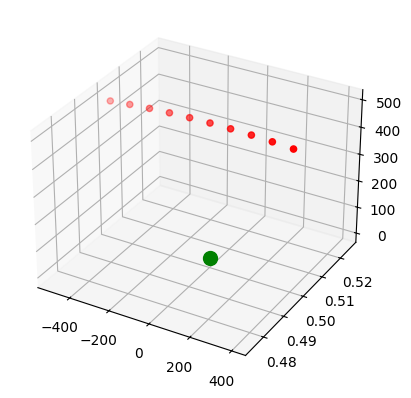

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.axes(projection='3d')

# 1. Plot Cloud Center (Pivot)
fig.scatter(LOOKAT[0], LOOKAT[1], LOOKAT[2], color='green', s=100, label='Cloud Center')

# 2. Extract and Plot Original Positions (Red)
# From your StringOfPearls output
orig_x, orig_y, orig_z = sat_positions.T
fig.scatter(orig_x, orig_y, orig_z, c='red', marker='o', label='Original')

# 3. Extract and Plot Rotated Positions (Blue)
# Calculated using ROT_TOTAL
rot_x = [p[0] for p in transformed_sensor_list]
rot_y = [p[1] for p in transformed_sensor_list]
rot_z = [p[2] for p in transformed_sensor_list]
fig.scatter(rot_x, rot_y, rot_z, c='blue', marker='^', label=f'Rotated {theta_deg}°')

# 4. Draw lines to show they point to the same LOOKAT
for i in range(len(orig_x)):
    fig.plot([orig_x[i], LOOKAT[0]], [orig_y[i], LOOKAT[1]], [orig_z[i], LOOKAT[2]], 'r--', alpha=0.3)
    fig.plot([rot_x[i], LOOKAT[0]], [rot_y[i], LOOKAT[1]], [rot_z[i], LOOKAT[2]], 'b--', alpha=0.3)

fig.set_xlabel('X [km]')
fig.set_ylabel('Y [km]')
fig.set_zlabel('Z [km]')
fig.legend()
plt.show()